<a href="https://colab.research.google.com/github/Prakhar20Srivastava/assignment-01-bitsom_ba_2511927/blob/main/part4_vector_db_embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


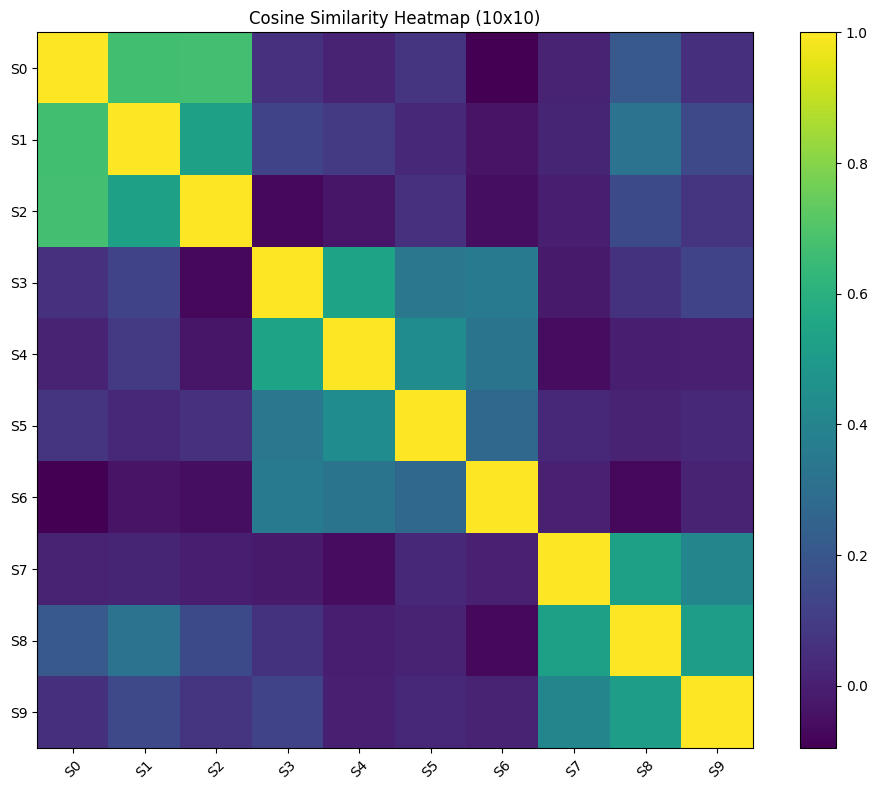


Query: The bowler took three wickets in one over

Top 2 most similar sentences:
- India dominates the sport of Cricket (Score: 0.4707)
- Cricket is played on a pitch of 22 yards (Score: 0.4506)


In [1]:
# Install required libraries (run once in Colab)
!pip install -q sentence-transformers scikit-learn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# Load a pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define sample sentences
sentences = [
    "Cricket is played across 20 countries in the world",
    "India dominates the sport of Cricket",
    "Cricket is played on a pitch of 22 yards",
    "Cooking is one of the hardest jobs in the world",
    "Women love cooking for their families",
    "Proper kitchen setup should be provided for cooking in restaurants",
    "Early man started cooking with the discovery of fire",
    "Cybersecurity is becoming increasingly important for personal identifiable information",
    "Cybersecurity crimes are increasing in India",
    "Poor cybersecurity strategy makes a company vulnerable to cyber attacks"
]

# Generate vector embeddings
vectors = model.encode(sentences)

print(f"Embedding shape: {vectors.shape}")

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(vectors)

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix)
plt.colorbar()

# Add labels
plt.xticks(ticks=range(len(sentences)), labels=[f"S{i}" for i in range(len(sentences))], rotation=45)
plt.yticks(ticks=range(len(sentences)), labels=[f"S{i}" for i in range(len(sentences))])

plt.title("Cosine Similarity Heatmap (10x10)")
plt.tight_layout()
plt.show()


# New query sentence
query = "The bowler took three wickets in one over"

# Encode the query
query_vector = model.encode([query])

# Compute similarity with existing sentence vectors
query_similarities = cosine_similarity(query_vector, vectors)[0]

# Get top 2 most similar sentences
top_indices = np.argsort(query_similarities)[-2:][::-1]

print(f"\nQuery: {query}\n")

print("Top 2 most similar sentences:")
for idx in top_indices:
    print(f"- {sentences[idx]} (Score: {query_similarities[idx]:.4f})")